PADDING IS HAPPENING IN collate_fn!

Batch Size: 4
Spectrogram Shape: torch.Size([4, 64, 1517])
Input Lengths: tensor([1046,  649, 1436, 1517])
Target Lengths: tensor([141, 103, 231, 261])

✓ All spectrograms padded to SAME time dimension!


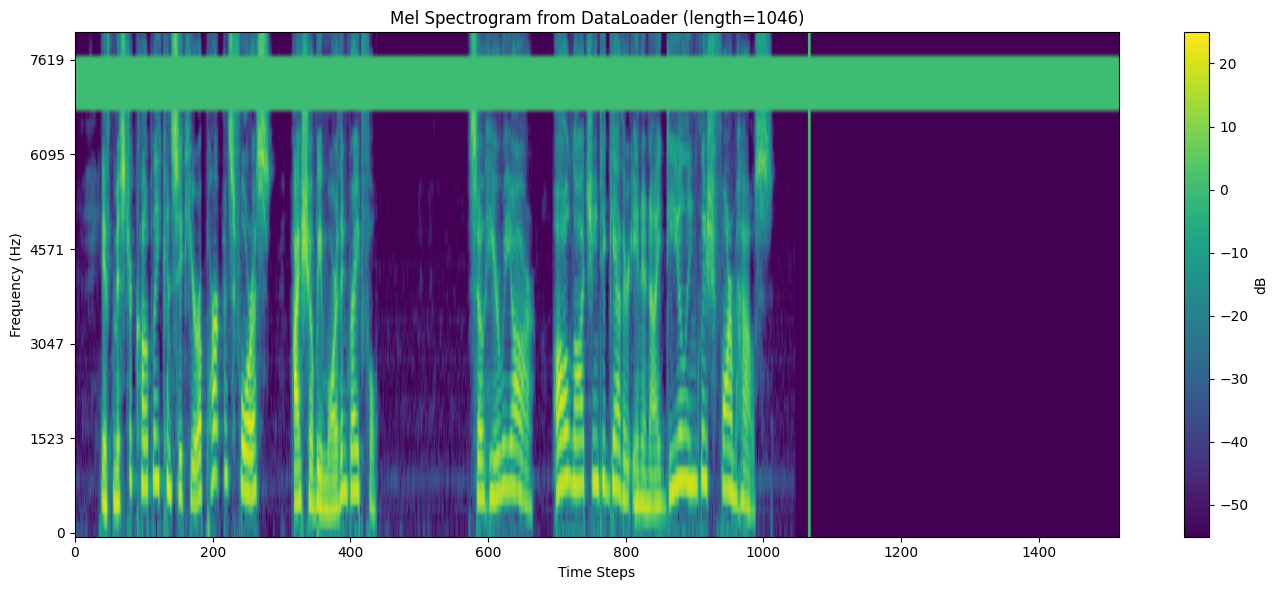

In [1]:
import torchaudio
import torch
from IPython.display import display
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

from model.helpers import collate_fn
from model.helpers import spec_aug

# Dataset setup
root = "/home/student/GOATS422/Notarius/datasets"
train_ds = torchaudio.datasets.LIBRISPEECH(root=root, url="train-clean-100", download=False)

# Spectrogram transform
n_fft = 400
n_mels = 64
sample_rate = 16000

spec_transform = nn.Sequential(
    torchaudio.transforms.MelSpectrogram(n_fft=n_fft, sample_rate=sample_rate, hop_length=160, n_mels=n_mels),
    torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)
)

# Create DataLoader with batch_size=10 to see padding in action
dataloader = DataLoader(train_ds, batch_size=4, shuffle=True, collate_fn=collate_fn, num_workers=0)

# Get one batch
batch = next(iter(dataloader))
spectrogram_batch, targets_batch, input_lengths, target_lengths = batch

print("=" * 60)
print("PADDING IS HAPPENING IN collate_fn!")
print("=" * 60)
print(f"\nBatch Size: {spectrogram_batch.shape[0]}")
print(f"Spectrogram Shape: {spectrogram_batch.shape}")
print(f"Input Lengths: {input_lengths}")
print(f"Target Lengths: {target_lengths}")
print("\n✓ All spectrograms padded to SAME time dimension!")

# Extract first sample from batch
spec1 = spectrogram_batch[0]
targets1 = targets_batch[0]

# Plot single spectrogram
fig, axes = plt.subplots(figsize=(14, 6))

nyquist = sample_rate / 2
freq_bins = np.linspace(0, nyquist, n_mels)
bin_indices = np.arange(0, n_mels, n_mels // 5)

im = axes.imshow(spec1.numpy(), aspect='auto', origin='lower', cmap='viridis')
axes.set_title(f"Mel Spectrogram from DataLoader (length={input_lengths[0].item()})")
axes.set_xlabel("Time Steps")
axes.set_ylabel("Frequency (Hz)")
axes.set_yticks(bin_indices)
axes.set_yticklabels([f"{int(freq_bins[i])}" for i in bin_indices])
plt.colorbar(im, ax=axes, label="dB")

plt.tight_layout()
plt.show()
